In [1]:
import time
import psutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from pathlib import Path

# Import your optimized modules
from panoseti_interface import PanosetiRun, PFFSequence
try:
    from jax_filters import KERNELS
except ImportError:
    # Define a fallback kernel if the file isn't found for the demo
    print("Warning: jax_filters.py not found, defining simple kernel.")
    @jax.jit
    def neighbor_kernel(img_batch, thresh=150, n_min=3):
        return img_batch > thresh
    KERNELS = {'neighbor': neighbor_kernel}

# Visual Styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

# Silence JAX warnings
jax.config.update("jax_enable_x64", True) # Ensure we handle int64 timestamps correctly if passed to JAX

In [33]:
# --- CONFIGURATION ---
data_dir = Path("data")
# run_dir = "obs_Palomar.start_2026-01-20T02:24:17Z.runtype_obs-test.pffd"
run_dir = "obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd"

run_dir_path = data_dir / run_dir

# ---------------------

print(f"Loading Run: {run_dir_path}...")
run = PanosetiRun(run_dir_path)

# Find a valid product (prefer ph256 or img16)
available = run.list_products()
target_product = next((p for p in available if 'ph256' in p), available[0] if available else None)

if not target_product:
    raise ValueError("No valid data products found!")

seq = run.get_product(target_product)
print(f"Selected Product: {seq.name}")
print(f"Total Frames: {len(seq):,}")
print(f"Time Range (ns): {seq.get_frame_time(0)} to {seq.get_frame_time(len(seq)-1)}")

Loading Run: data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd...
Selected Product: start_2026-02-09T09:47:30Z.dp_ph256.bpp_2.module_250
Total Frames: 485,753
Time Range (ns): 1770630456581456791 to 1770642151863612836


Loading Run: data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd...
Benchmarking Product: start_2026-02-09T09:47:30Z.dp_ph256.bpp_2.module_250
Total Frames: 485753

Running benchmarks...
1. Raw I/O Speed:    5,859,553 FPS
  Pre-loading data for RAM test...
2. RAM Compute Speed: 3,655,487 FPS
3. Full Pipeline:     1,473,496 FPS


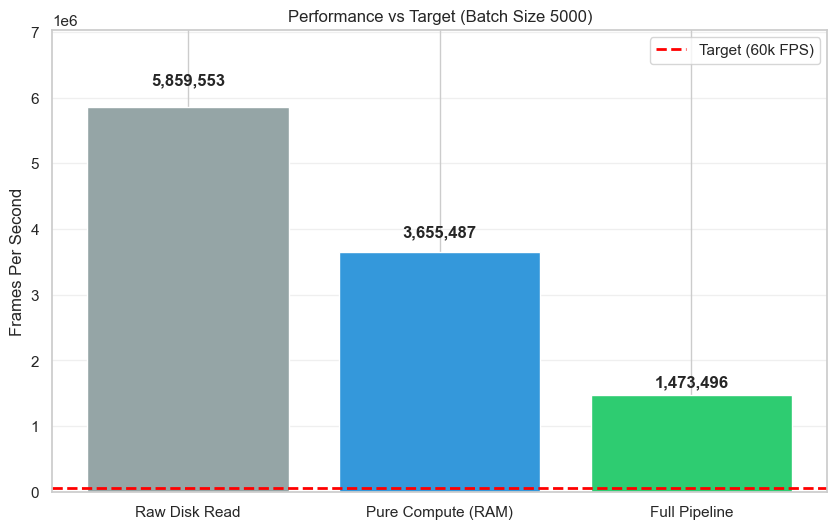

In [40]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp
from functools import partial
from panoseti_interface import PanosetiRun

# --- CONFIGURATION ---
# Update this path to your actual data file
run_dir = "data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd"
TARGET_FPS = 60_000
BATCH_SIZE = 5000 

print(f"Loading Run: {run_dir}...")
run = PanosetiRun(run_dir)
# Find a 'ph256' product (16x16 images)
prods = [p for p in run.list_products() if 'ph256' in p]
if not prods:
    # Fallback to any valid product if ph256 isn't found
    prods = run.list_products()
    
if not prods:
    raise ValueError("No data products found.")
    
seq = run.get_product(prods[0]) 

print(f"Benchmarking Product: {seq.name}")
print(f"Total Frames: {len(seq)}")

# --- DEFINITIONS ---

def block_jax_result(res):
    """Helper to block on a JAX result, handling tuples/lists."""
    if isinstance(res, (tuple, list)):
        # Block on the last element (usually the final mask)
        res[-1].block_until_ready()
    else:
        res.block_until_ready()

def bench_io_only(sequence, batch_size):
    """Scenario 1: Read from disk, do nothing (Dan's I/O test)"""
    start = time.perf_counter()
    cursor = 0
    total = 0
    while cursor < len(sequence):
        # get_image_array uses mmap to fetch bytes without parsing headers
        chunk = sequence.get_image_array(cursor, batch_size)
        if len(chunk) == 0: break
        # We do nothing here, just discard
        cursor += len(chunk)
        total += len(chunk)
    dt = time.perf_counter() - start
    if dt == 0: dt = 0.000001
    return total / dt

def bench_compute_only(sequence, batch_size):
    """Scenario 2: Compute in RAM (Dan's Compute test)"""
    # Pre-load data to RAM to remove I/O factor
    print("  Pre-loading data for RAM test...")
    # Load up to 50k frames, or the whole file if smaller
    load_count = min(len(sequence), 50000)
    ram_data = sequence.get_image_array(0, load_count) 
    jax_data = jnp.array(ram_data)
    
    # Compile Kernel
    from jax_filters import KERNELS
    params = {'thresh': 150, 'n_min': 3}
    kernel = jax.jit(jax.vmap(partial(KERNELS['neighbor'], **params)))
    
    # Warmup
    # Ensure we don't slice out of bounds if file is small
    safe_batch = min(batch_size, len(jax_data))
    res = kernel(jax_data[:safe_batch])
    block_jax_result(res)
    
    start = time.perf_counter()
    iterations = 50
    for _ in range(iterations):
        # Run kernel on RAM data
        res = kernel(jax_data[:safe_batch])
        block_jax_result(res)
        
    dt = time.perf_counter() - start
    if dt == 0: dt = 0.000001
    
    total_frames = iterations * safe_batch
    return total_frames / dt

def bench_full_pipeline(sequence, batch_size):
    """Scenario 3: The actual application"""
    from jax_filters import KERNELS
    params = {'thresh': 150, 'n_min': 3}
    kernel = jax.jit(jax.vmap(partial(KERNELS['neighbor'], **params)))
    
    start = time.perf_counter()
    cursor = 0
    total = 0
    # Limit full pipeline test to ~100k frames or file end to save time
    limit = min(len(sequence), 100000)
    
    while cursor < limit:
        # 1. Read
        chunk = sequence.get_image_array(cursor, batch_size)
        if len(chunk) == 0: break
        
        # 2. Compute
        jax_chunk = jnp.array(chunk)
        res = kernel(jax_chunk)
        block_jax_result(res)
        
        cursor += len(chunk)
        total += len(chunk)
        
    dt = time.perf_counter() - start
    if dt == 0: dt = 0.000001
    return total / dt

# --- EXECUTION ---
print("\nRunning benchmarks...")
fps_io = bench_io_only(seq, BATCH_SIZE)
print(f"1. Raw I/O Speed:    {fps_io:,.0f} FPS")

fps_compute = bench_compute_only(seq, BATCH_SIZE)
print(f"2. RAM Compute Speed: {fps_compute:,.0f} FPS")

fps_full = bench_full_pipeline(seq, BATCH_SIZE)
print(f"3. Full Pipeline:     {fps_full:,.0f} FPS")

# --- VISUALIZATION ---
results = {
    'Raw Disk Read': fps_io,
    'Pure Compute (RAM)': fps_compute,
    'Full Pipeline': fps_full
}

plt.figure(figsize=(10, 6))
bars = plt.bar(results.keys(), results.values(), color=['#95a5a6', '#3498db', '#2ecc71'])

# Add Target Line
plt.axhline(TARGET_FPS, color='red', linestyle='--', linewidth=2, label='Target (60k FPS)')

# Annotate bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.05), f"{yval:,.0f}", ha='center', va='bottom', fontweight='bold')

plt.ylabel("Frames Per Second")
plt.title(f"Performance vs Target (Batch Size {BATCH_SIZE})")
plt.legend()
plt.ylim(0, max(results.values()) * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.show()

Loading Run: data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd...
Batch    | FPS        | Latency (ms)    | Overhead  
-------------------------------------------------------
1        | 13,702    | 0.073           | 72.0 us
2        | 27,687    | 0.072           | 70.2 us
4        | 56,371    | 0.071           | 67.0 us
8        | 112,922    | 0.071           | 62.8 us
16       | 209,519    | 0.076           | 60.4 us
32       | 370,394    | 0.086           | 54.4 us
64       | 554,297    | 0.115           | 51.5 us
128      | 930,382    | 0.138           | 9.6 us
256      | 1,339,118    | 0.191           | -64.8 us
512      | 1,961,460    | 0.261           | -251.0 us
1024     | 3,155,103    | 0.325           | -699.4 us
2048     | 3,630,698    | 0.564           | -1483.9 us
4096     | 4,145,839    | 0.988           | -3108.0 us
8192     | 4,252,615    | 1.926           | -6265.7 us
16384    | 4,849,197    | 3.379           | -13005.3 us
32768    | 5,186,799    | 6.318

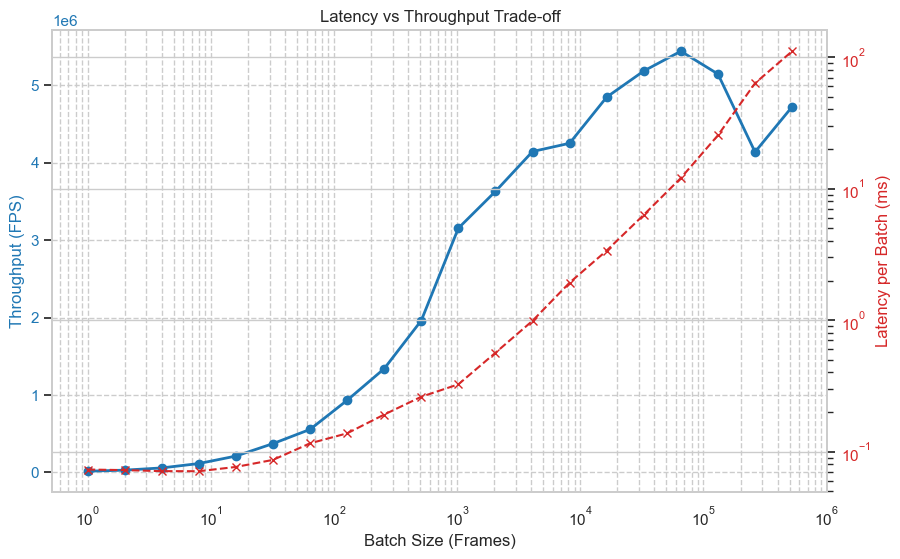

In [43]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from functools import partial
from panoseti_interface import PanosetiRun
from jax_filters import KERNELS

# --- CONFIGURATION ---
run_dir = "data/obs_Palomar.start_2026-02-09T09_46_29Z.runtype_obs-test.pffd"
BATCH_SIZES = 2**np.arange(20)
N_ITERS = 10

# Load Data
print(f"Loading Run: {run_dir}...")
run = PanosetiRun(run_dir)
seq = [run.get_product(p) for p in run.list_products() if 'ph256' in p][0]

# Prepare Kernel
params = {'thresh': 150, 'n_min': 3}
base_kernel = KERNELS['neighbor']

results = []
print(f"{'Batch':<8} | {'FPS':<10} | {'Latency (ms)':<15} | {'Overhead':<10}")
print("-" * 55)

for b_size in BATCH_SIZES:
    # Compile specifically for this batch size
    vmapped = jax.jit(jax.vmap(partial(base_kernel, **params)))
    
    # Warmup with dummy data
    dummy = jnp.zeros((b_size, 16, 16), dtype=jnp.int16)
    _ = vmapped(dummy)
    _[-1].block_until_ready()
    
    # Run Benchmark (Full Pipeline: Read + Compute)
    start = time.perf_counter()
    processed = 0
    cursor = 0
    
    # Run for 1.0 second
    loop_start = time.perf_counter()
    while (time.perf_counter() - loop_start) < 1.0:
        chunk = seq.get_image_array(cursor, b_size)
        if len(chunk) < b_size:
            cursor = 0 # Wrap
            chunk = seq.get_image_array(0, b_size)
            
        jax_chunk = jnp.array(chunk)
        res = vmapped(jax_chunk)
        res[-1].block_until_ready()
        
        processed += len(chunk)
        cursor += len(chunk)
        
    dt = time.perf_counter() - loop_start
    fps = processed / dt
    latency = (dt / processed) * b_size * 1000 # Latency per BATCH
    
    # Approximate overhead per batch (vs ideal infinite batch speed ~1M FPS)
    # 1M FPS = 1us per frame. 
    # Current time per frame = 1/FPS. Overhead = Current - Ideal.
    overhead_us = (1/fps - 1e-6) * 1e6 * b_size
    
    print(f"{b_size:<8} | {fps:,.0f}    | {latency:.3f}           | {overhead_us:.1f} us")
    results.append({'Batch Size': b_size, 'FPS': fps, 'Latency (ms)': latency})

# --- Plotting ---
df = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Batch Size (Frames)')
ax1.set_ylabel('Throughput (FPS)', color=color)
ax1.plot(df['Batch Size'], df['FPS'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.grid(True, which="both", ls="--")

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Latency per Batch (ms)', color=color)
ax2.plot(df['Batch Size'], df['Latency (ms)'], color=color, linestyle='--', marker='x')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_yscale('log')

plt.title("Latency vs Throughput Trade-off")
plt.show()

Loading data to RAM for Compute Benchmark...
Benchmarking 'neighbor' Kernel...


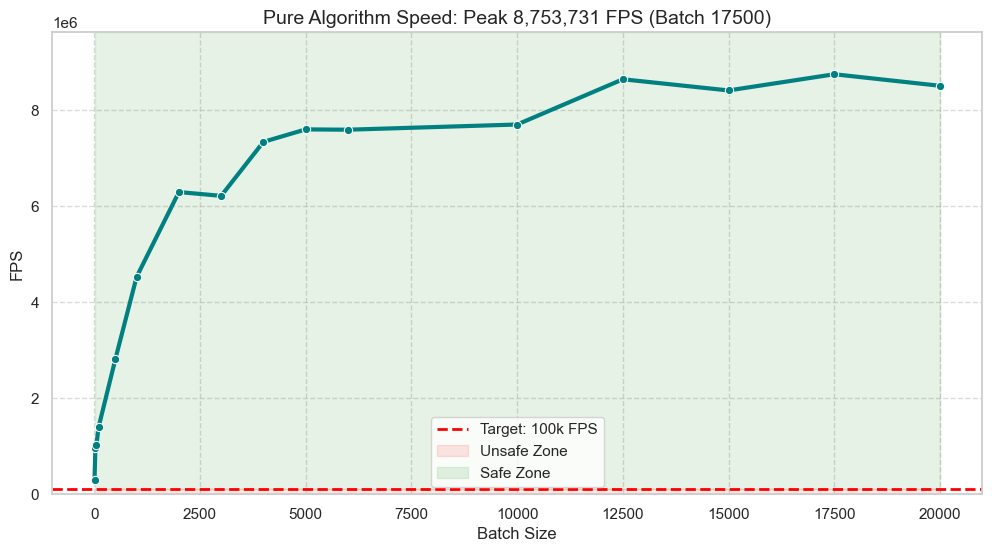

Verdict: The algorithm is 87.5x faster than required.


In [27]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from functools import partial

# --- SETUP ---
TARGET_FPS = 100_000
BATCH_SIZES = [5, 25, 50, 100, 500, 1_000, 2_000, 3_000, 4_000, 5_000, 6_000,
               10_000, 12_500, 15_000, 17_500, 20_000
              ]

N_ITERS = 1_000

# Load Data Once to RAM for Pure Compute Test
print("Loading data to RAM for Compute Benchmark...")
# Assuming 'seq' is already defined from previous cells
sample_data = seq.get_image_array(0, 20000) 
jax_data_full = jnp.array(sample_data)

# Setup Kernel
kernel_name = 'neighbor'
params = {'thresh': 150, 'n_min': 3}
base_kernel = KERNELS[kernel_name]

results = []

print(f"Benchmarking '{kernel_name}' Kernel...")

for b_size in BATCH_SIZES:
    # Slice data
    batch_input = jax_data_full[:b_size]
    
    # Compile (JIT) specifically for this shape
    vmapped_kernel = jax.jit(jax.vmap(partial(base_kernel, **params)))
    
    # Warmup
    _ = vmapped_kernel(batch_input)
    if isinstance(_, (tuple, list)): _[-1].block_until_ready()
    else: _.block_until_ready()
    
    # Timing Loop
    batch_times = []
    for _ in range(N_ITERS):
        t0 = time.perf_counter()
        res = vmapped_kernel(batch_input)
        if isinstance(res, (tuple, list)): res[-1].block_until_ready()
        else: res.block_until_ready()
        batch_times.append(time.perf_counter() - t0)
    
    avg_time = np.mean(batch_times)
    fps = b_size / avg_time
    
    results.append({
        'Batch Size': b_size,
        'FPS': fps,
        'Latency (ms)': avg_time * 1000
    })

# --- VISUALIZATION ---
df = pd.DataFrame(results)

plt.figure(figsize=(12, 6))
ax = sns.lineplot(data=df, x='Batch Size', y='FPS', marker='o', linewidth=3, color='teal')

# Add Target Line
plt.axhline(TARGET_FPS, color='red', linestyle='--', linewidth=2, label=f'Target: {TARGET_FPS/1000:.0f}k FPS')

# Annotate
max_fps = df['FPS'].max()
best_batch = df.loc[df['FPS'].idxmax(), 'Batch Size']
plt.title(f"Pure Algorithm Speed: Peak {max_fps:,.0f} FPS (Batch {best_batch})", fontsize=14)
plt.fill_between(df['Batch Size'], 0, TARGET_FPS, color='red', alpha=0.1, label='Unsafe Zone')
plt.fill_between(df['Batch Size'], TARGET_FPS, max_fps*1.1, color='green', alpha=0.1, label='Safe Zone')

plt.ylim(0, max_fps * 1.1)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Verdict: The algorithm is {max_fps/TARGET_FPS:.1f}x faster than required.")

Running System Stress Test (I/O + Compute) for 30s...


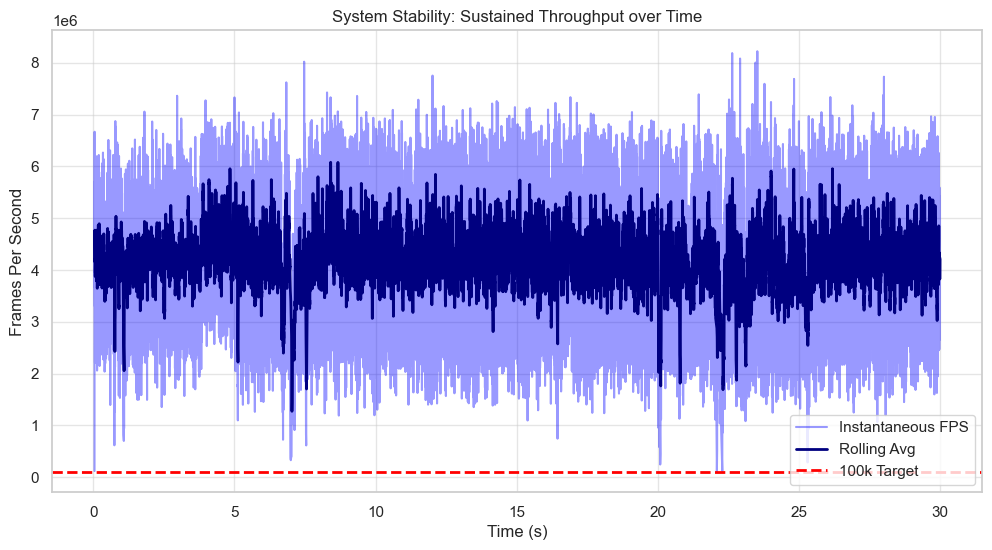

Average Sustained Speed: 3,840,727 FPS
System clears 100k target with 38.4x headroom.


In [31]:
# --- CONFIGURATION ---
TEST_DURATION = 30  # seconds
BATCH_SIZE = 5000   # Use optimal batch from previous test
TARGET_FPS = 100_000

print(f"Running System Stress Test (I/O + Compute) for {TEST_DURATION}s...")

# Setup JAX
vmapped_kernel = jax.jit(jax.vmap(partial(base_kernel, **params)))

# Loop State
cursor = 0
total_processed = 0
start_time = time.perf_counter()
fps_log = []
timestamps = []

while (time.perf_counter() - start_time) < TEST_DURATION:
    loop_start = time.perf_counter()
    
    # 1. Fetch (I/O)
    # Handle wrap-around for continuous testing
    if cursor + BATCH_SIZE > len(seq):
        cursor = 0
    
    raw_data = seq.get_image_array(cursor, BATCH_SIZE)
    if len(raw_data) == 0: break
    
    # 2. Compute (JAX)
    jax_data = jnp.array(raw_data)
    res = vmapped_kernel(jax_data)
    if isinstance(res, (tuple, list)): res[-1].block_until_ready()
    else: res.block_until_ready()
    
    # 3. Measure
    dt = time.perf_counter() - loop_start
    current_fps = len(raw_data) / dt
    
    fps_log.append(current_fps)
    timestamps.append(time.perf_counter() - start_time)
    
    cursor += len(raw_data)
    total_processed += len(raw_data)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot Instantaneous FPS
plt.plot(timestamps, fps_log, color='blue', alpha=0.4, label='Instantaneous FPS')

# Plot Rolling Average
window = 10
rolling_avg = np.convolve(fps_log, np.ones(window)/window, mode='valid')
plt.plot(timestamps[window-1:], rolling_avg, color='navy', linewidth=2, label='Rolling Avg')

# Target Line
plt.axhline(TARGET_FPS, color='red', linestyle='--', linewidth=2, label='100k Target')

plt.title("System Stability: Sustained Throughput over Time")
plt.xlabel("Time (s)")
plt.ylabel("Frames Per Second")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)
plt.show()

avg_fps = total_processed / (time.perf_counter() - start_time)
print(f"Average Sustained Speed: {avg_fps:,.0f} FPS")
if avg_fps > TARGET_FPS:
    print(f"System clears 100k target with {avg_fps/TARGET_FPS:.1f}x headroom.")
else:
    print("WARNING: System failed to meet throughput target.")

Running 100000 random seeks...


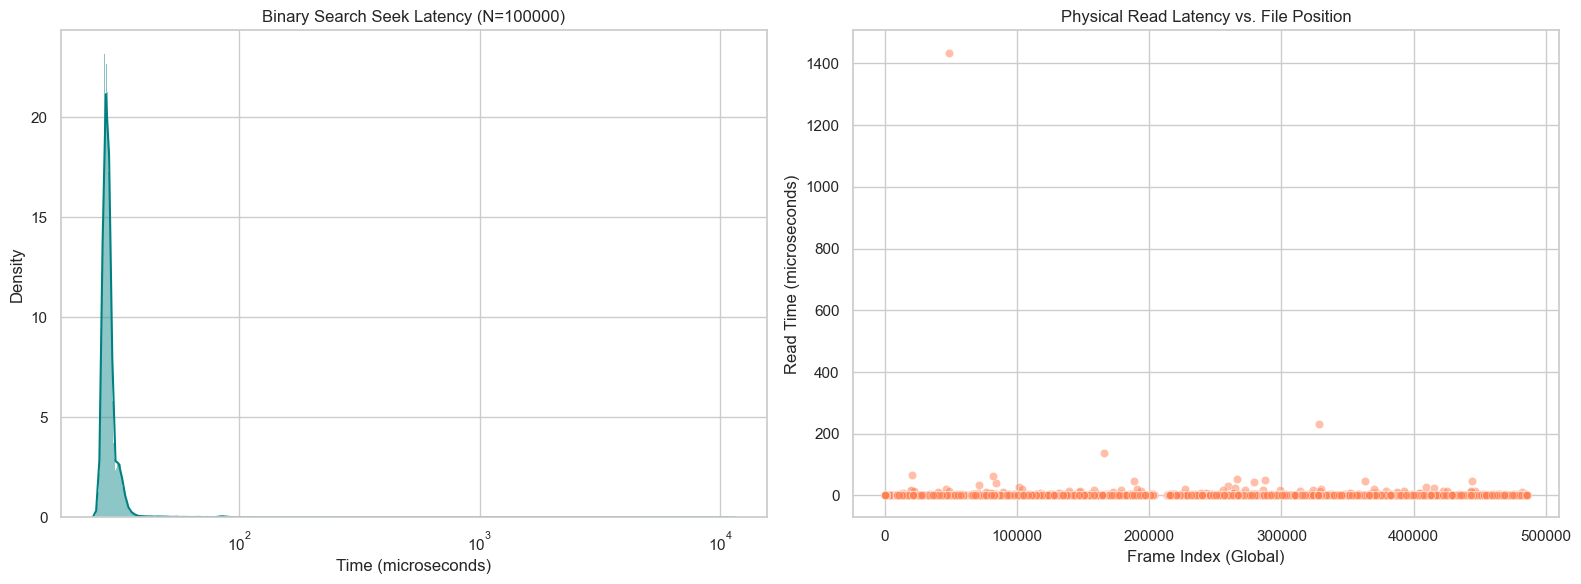

Avg Seek Time: 29.34 μs
Avg Read Time: 1.21 μs


In [3]:
n_samples = 100_000
total_frames = len(seq)

# 1. Generate random target timestamps within the file's range
t_start = seq.get_frame_time(0)
t_end = seq.get_frame_time(total_frames - 1)
# Create random target times (int64)
random_times = np.random.randint(t_start, t_end, n_samples, dtype=np.int64)

seek_latencies = []
read_latencies = []
found_indices = []

print(f"Running {n_samples} random seeks...")

start_bench = time.perf_counter()

for target_t in random_times:
    # A. Benchmark Binary Search Seek
    t0 = time.perf_counter()
    idx = seq.seek_time(target_t)
    t1 = time.perf_counter()
    seek_latencies.append((t1 - t0) * 1e6) # microseconds

    # B. Benchmark Header Read (at the found index)
    # This tests mmap random access latency
    t2 = time.perf_counter()
    actual_t = seq.get_frame_time(idx)
    t3 = time.perf_counter()
    read_latencies.append((t3 - t2) * 1e6) # microseconds

    found_indices.append(idx)

total_bench_time = time.perf_counter() - start_bench

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Seek Time Histogram
sns.histplot(seek_latencies, kde=True, ax=axes[0], color='teal', stat='density', log_scale=True)
axes[0].set_title(f"Binary Search Seek Latency (N={n_samples})")
axes[0].set_xlabel("Time (microseconds)")
# axes[0].set_ylabel("Count")

# Plot 2: Random Access vs File Position
# Shows if seeking at the end of the file is slower (it shouldn't be with mmap)
sns.scatterplot(x=found_indices, y=read_latencies, ax=axes[1], alpha=0.5, color='coral')
axes[1].set_title("Physical Read Latency vs. File Position")
axes[1].set_xlabel("Frame Index (Global)")
axes[1].set_ylabel("Read Time (microseconds)")

plt.tight_layout()
plt.show()

print(f"Avg Seek Time: {np.mean(seek_latencies):.2f} μs")
print(f"Avg Read Time: {np.mean(read_latencies):.2f} μs")

Benchmarking Batch Sizes: [100, 500, 1000, 2000, 5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000]
------------------------------------------------------------
Batch Size      | Mean Time (ms)  | FPS            
------------------------------------------------------------
100             | 0.091           | 1,093,344
500             | 0.181           | 2,755,201
1000            | 0.212           | 4,718,446
2000            | 0.332           | 6,020,754
5000            | 0.620           | 8,059,220
10000           | 1.198           | 8,348,616
20000           | 2.230           | 8,969,119
30000           | 2.768           | 10,837,208
40000           | 3.407           | 11,739,294
50000           | 4.455           | 11,224,138
60000           | 5.023           | 11,944,185
70000           | 6.595           | 10,614,719
80000           | 7.546           | 10,601,902
90000           | 10.033          | 8,970,130
100000          | 8.892           | 11,245,994


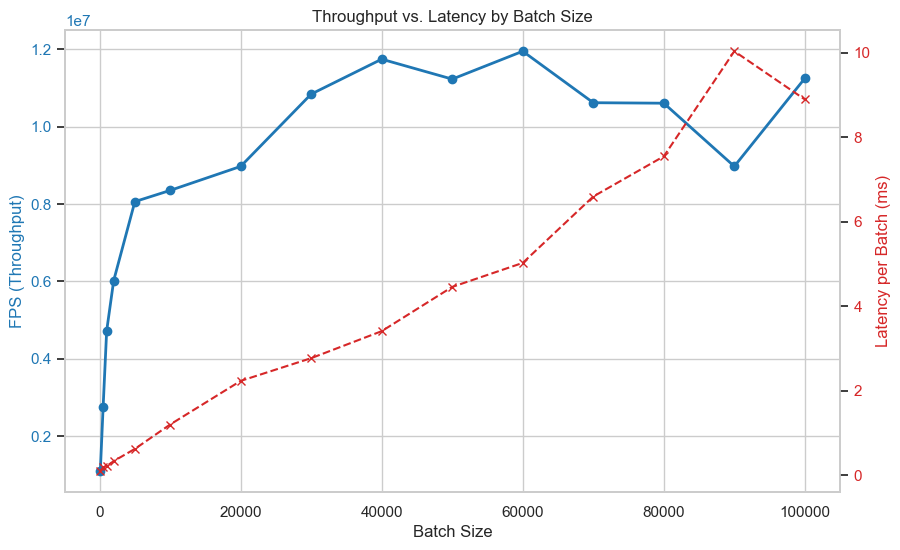

In [15]:
# --- Cell: Batch Size Parameter Study ---
from functools import partial
import pandas as pd

# Configuration
BATCH_SIZES = [100, 500, 1_000, 2_000, 5_000, 10_000, 20_000, 30_000, 40_000, 50_000, 60_000, 70_000, 80_000, 90_000, 100_000]
N_ITERS = 50
KERNEL_NAME = 'neighbor'
PARAMS = {'thresh': 150, 'n_min': 3}

results = []
base_kernel = KERNELS[KERNEL_NAME]

print(f"Benchmarking Batch Sizes: {BATCH_SIZES}")
print("-" * 60)
print(f"{'Batch Size':<15} | {'Mean Time (ms)':<15} | {'FPS':<15}")
print("-" * 60)

for b_size in BATCH_SIZES:
    # 1. Prepare Data (Fetch distinct batch for this size)
    # Ensure we don't go out of bounds
    safe_size = min(b_size, len(seq))
    raw_batch = seq.get_image_array(0, safe_size)
    jax_batch = jnp.array(raw_batch)
    
    # 2. Compile specific vmapped kernel for this shape
    # Note: JAX recompiles if shapes change, so we include compilation time in "Warmup"
    vmapped_kernel = jax.jit(jax.vmap(partial(base_kernel, **PARAMS)))
    
    # Warmup
    _ = vmapped_kernel(jax_batch)
    if isinstance(_, (tuple, list)): _[-1].block_until_ready()
    else: _.block_until_ready()
    
    # 3. Run Benchmark
    times = []
    for _ in range(N_ITERS):
        t0 = time.perf_counter()
        res = vmapped_kernel(jax_batch)
        if isinstance(res, (tuple, list)): res[-1].block_until_ready()
        else: res.block_until_ready()
        times.append(time.perf_counter() - t0)
    
    avg_time = np.mean(times)
    fps = safe_size / avg_time
    
    results.append({
        'Batch Size': b_size,
        'Time (ms)': avg_time * 1000,
        'FPS': fps
    })
    
    print(f"{b_size:<15} | {avg_time*1000:<15.3f} | {fps:,.0f}")

# --- Visualization ---
df_batch = pd.DataFrame(results)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('FPS (Throughput)', color=color)
ax1.plot(df_batch['Batch Size'], df_batch['FPS'], color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Latency per Batch (ms)', color=color)  # we already handled the x-label with ax1
ax2.plot(df_batch['Batch Size'], df_batch['Time (ms)'], color=color, linestyle='--', marker='x')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False)

plt.title("Throughput vs. Latency by Batch Size")
plt.show()

Starting Ring Stress Test for 5 seconds...
Dataset Size: 485,753 frames (approx 0.31 GB)
Test Complete. Completed 34 full passes over the data.


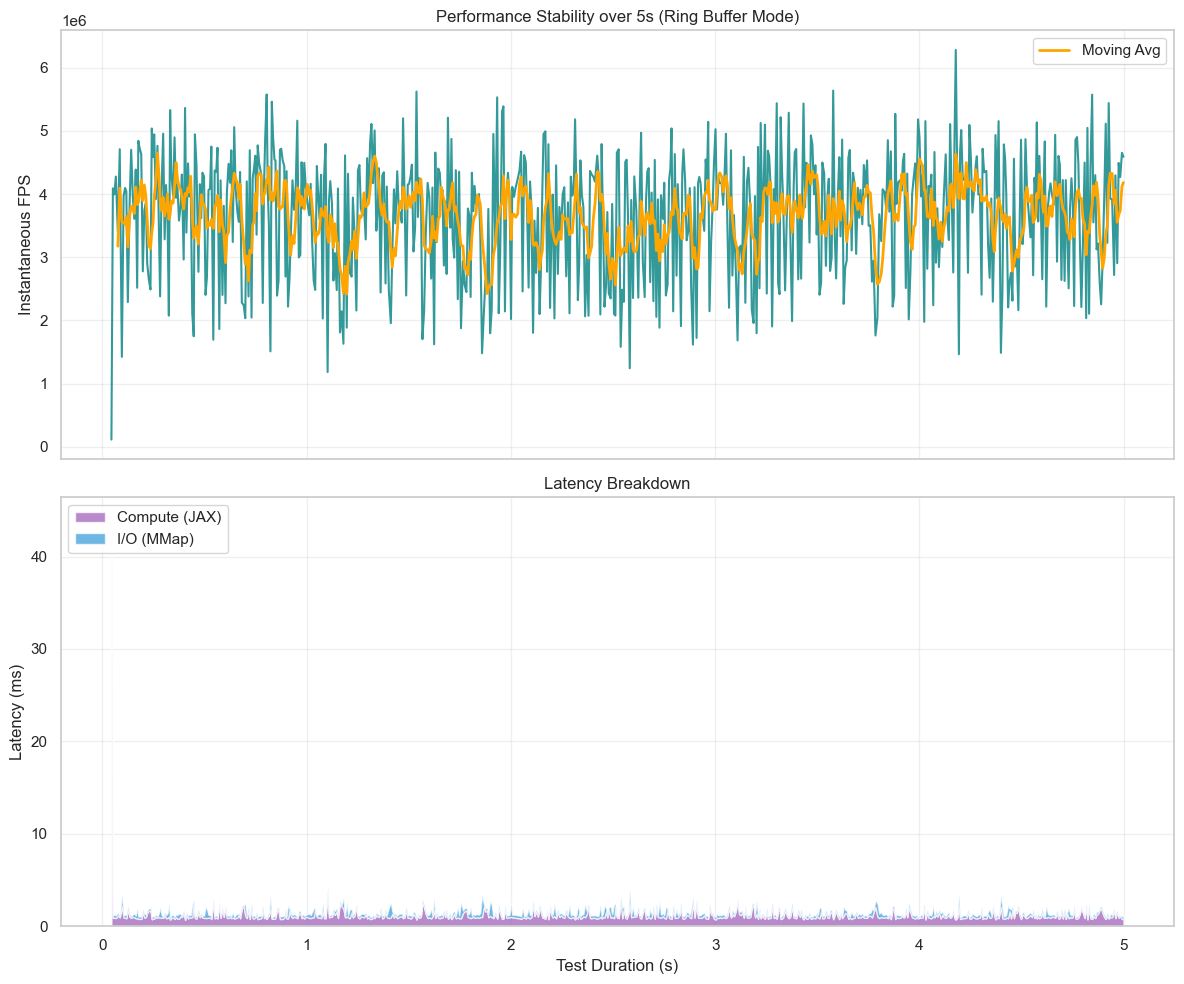

In [9]:
# --- Cell: Virtual Memory Stress Test (Ring Pattern) ---

# Configuration
TEST_DURATION_SEC = 5   # Run for this many seconds
BATCH_SIZE = 5000        # Size from previous test that worked well
REPORT_EVERY = 5         # Record stats every N batches to reduce overhead

print(f"Starting Ring Stress Test for {TEST_DURATION_SEC} seconds...")
print(f"Dataset Size: {len(seq):,} frames (approx {len(seq)*seq.frame_config.frame_size/1e9:.2f} GB)")

# JAX Setup
params = {'thresh': 150, 'n_min': 3}
kernel = KERNELS['neighbor']
vmapped_kernel = jax.jit(jax.vmap(partial(kernel, **params)))

# State
cursor = 0
total_frames = len(seq)
start_time = time.perf_counter()
history = []

iter_count = 0
passes = 0

while (time.perf_counter() - start_time) < TEST_DURATION_SEC:
    batch_start_t = time.perf_counter()
    
    # 1. IO: Handle Ring Wrap-around
    # If a batch straddles the end, get_image_array handles truncation, 
    # but we need to manually fetch the rest from the start to maintain constant batch size.
    
    frames_to_read = BATCH_SIZE
    io_t0 = time.perf_counter()
    
    # Standard read
    chunk1 = seq.get_image_array(cursor, frames_to_read)
    
    # Wrap-around logic
    if len(chunk1) < BATCH_SIZE:
        passes += 1
        remainder = BATCH_SIZE - len(chunk1)
        chunk2 = seq.get_image_array(0, remainder)
        if len(chunk2) > 0:
            if len(chunk1) > 0:
                raw_data = np.concatenate([chunk1, chunk2])
            else:
                raw_data = chunk2
        else:
            raw_data = chunk1 # Should only happen if empty dataset
            
        cursor = remainder # Reset cursor
    else:
        raw_data = chunk1
        cursor += BATCH_SIZE
        
    io_dt = time.perf_counter() - io_t0
    
    # 2. Compute
    comp_t0 = time.perf_counter()
    jax_data = jnp.array(raw_data)
    res = vmapped_kernel(jax_data)
    if isinstance(res, (tuple, list)): res[-1].block_until_ready()
    else: res.block_until_ready()
    comp_dt = time.perf_counter() - comp_t0
    
    # Record
    total_dt = time.perf_counter() - batch_start_t
    if iter_count % REPORT_EVERY == 0:
        # Check RAM usage
        mem = psutil.virtual_memory().percent
        history.append({
            'Time': time.perf_counter() - start_time,
            'IO Time': io_dt,
            'Compute Time': comp_dt,
            'Total FPS': BATCH_SIZE / total_dt,
            'RAM %': mem
        })
    
    iter_count += 1

print(f"Test Complete. Completed {passes} full passes over the data.")

# --- Visualization ---
df_stress = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: FPS Stability
ax1.plot(df_stress['Time'], df_stress['Total FPS'], color='teal', alpha=0.8)
ax1.set_ylabel("Instantaneous FPS")
ax1.set_title(f"Performance Stability over {TEST_DURATION_SEC}s (Ring Buffer Mode)")
ax1.grid(True, alpha=0.3)

# Add moving average
ax1.plot(df_stress['Time'], df_stress['Total FPS'].rolling(window=5).mean(), 
         color='orange', linewidth=2, label='Moving Avg')
ax1.legend()

# Plot 2: Latency Breakdown (Stacked Area)
ax2.stackplot(df_stress['Time'], 
              df_stress['Compute Time'] * 1000, 
              df_stress['IO Time'] * 1000, 
              labels=['Compute (JAX)', 'I/O (MMap)'],
              colors=['#9b59b6', '#3498db'], alpha=0.7)
ax2.set_ylabel("Latency (ms)")
ax2.set_xlabel("Test Duration (s)")
ax2.set_title("Latency Breakdown")
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Fetching batch of 5000 frames to RAM...
Warming up JAX (JIT compilation)...
Warmup complete.
Running 1000 iterations...


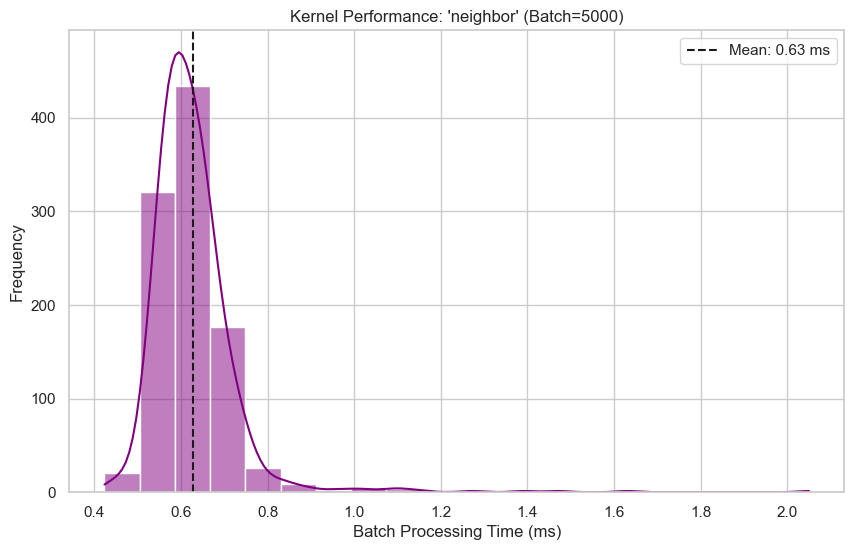

Performance Summary:
  Batch Size: 5000
  Mean Time:  0.627 ms
  Throughput: 7,971,823 Frames/Second


In [5]:
# Cell 4: Benchmark 2 - JAX Kernel Histograms (CORRECTED)
from functools import partial

# Configuration
BATCH_SIZE = 5000
N_ITERS = 1000
KERNEL_NAME = 'neighbor'
PARAMS = {'thresh': 150, 'n_min': 3}

# 1. Prepare Data (Fetch once to isolate compute from I/O)
print(f"Fetching batch of {BATCH_SIZE} frames to RAM...")
raw_batch = seq.get_image_array(0, BATCH_SIZE)
jax_batch = jnp.array(raw_batch)

# --- FIX: Create vmapped kernel ---
# We bind the parameters using partial, then vmap over the batch axis, then JIT compile.
base_kernel = KERNELS[KERNEL_NAME]
vmapped_kernel = jax.jit(jax.vmap(partial(base_kernel, **PARAMS)))

# 2. Warmup (JIT Compilation)
print("Warming up JAX (JIT compilation)...")
# call the vmapped function, not the base one
_ = vmapped_kernel(jax_batch)
# Force execution
if isinstance(_, (tuple, list)): _[-1].block_until_ready()
else: _.block_until_ready()
print("Warmup complete.")

# 3. Benchmark Loop
compute_times = []
print(f"Running {N_ITERS} iterations...")

for i in range(N_ITERS):
    t0 = time.perf_counter()
    
    # Run Kernel
    res = vmapped_kernel(jax_batch)
    
    # CRITICAL: JAX is asynchronous. We must block to measure true time.
    if isinstance(res, (tuple, list)):
        res[-1].block_until_ready()
    else:
        res.block_until_ready()
        
    t1 = time.perf_counter()
    compute_times.append((t1 - t0) * 1000) # milliseconds

# 4. Calculate FPS
avg_time_ms = np.mean(compute_times)
# Avoid division by zero if it's too fast
if avg_time_ms == 0: avg_time_ms = 0.001
fps = BATCH_SIZE / (avg_time_ms / 1000)

# --- Plotting ---
plt.figure(figsize=(10, 6))
sns.histplot(compute_times, kde=True, color='purple', bins=20)
plt.axvline(avg_time_ms, color='k', linestyle='--', label=f'Mean: {avg_time_ms:.2f} ms')
plt.title(f"Kernel Performance: '{KERNEL_NAME}' (Batch={BATCH_SIZE})")
plt.xlabel("Batch Processing Time (ms)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print(f"Performance Summary:")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Mean Time:  {avg_time_ms:.3f} ms")
print(f"  Throughput: {fps:,.0f} Frames/Second")

Running pipeline stress test on 50000 frames...


/var/folders/5q/9jqcz6pj3053zxqf_d22qb680000gr/T/ipykernel_44038/3172475939.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Stage', y='Duration', data=df, palette="Set2")


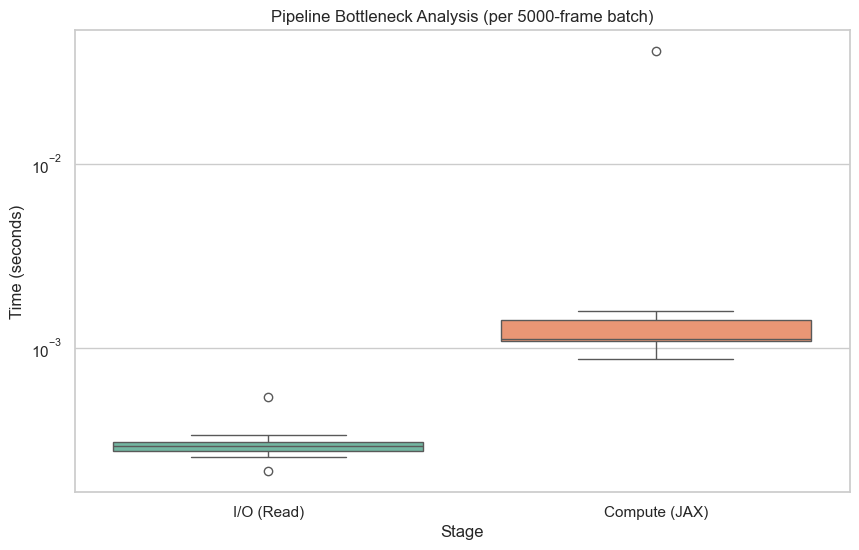

In [6]:
# Cell 5: Full Pipeline Stress Test (CORRECTED)
from functools import partial

# Stress test reading AND processing sequentially
TOTAL_FRAMES_TO_TEST = 50000
BATCH = 5000
params = {'thresh': 150, 'n_min': 3}
kernel = KERNELS['neighbor']

# This tells JAX: "Apply this function to every item in the batch (axis 0)"
# We jit it once here for maximum performance.
vmapped_kernel = jax.jit(jax.vmap(partial(kernel, **params)))

io_times = []
compute_times = []

print(f"Running pipeline stress test on {TOTAL_FRAMES_TO_TEST} frames...")

curr = 0
while curr < TOTAL_FRAMES_TO_TEST:
    # 1. Measure I/O (mmap copy)
    t0 = time.perf_counter()
    data = seq.get_image_array(curr, BATCH)
    t1 = time.perf_counter()
    
    if len(data) == 0: break
    
    # 2. Measure Compute (JAX)
    jax_data = jnp.array(data)
    
    res = vmapped_kernel(jax_data)
    
    # Block to ensure computation finishes before stopping the clock
    if isinstance(res, (tuple, list)): 
        res[-1].block_until_ready()
    else: 
        res.block_until_ready()
        
    t2 = time.perf_counter()
    
    io_times.append(t1 - t0)
    compute_times.append(t2 - t1)
    
    curr += len(data)

# Dataframe for Seaborn
df = pd.DataFrame({
    'Duration': io_times + compute_times,
    'Stage': ['I/O (Read)'] * len(io_times) + ['Compute (JAX)'] * len(compute_times)
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Stage', y='Duration', data=df, palette="Set2")
plt.title("Pipeline Bottleneck Analysis (per 5000-frame batch)")
plt.ylabel("Time (seconds)")
plt.yscale('log') 
plt.show()

Fetching 485753 timestamps for analysis...
Fetched in 0.53s (914,046 headers/sec)

--- Chronology Report ---
Total Frames:       485,753
Out-of-Order Jumps: 787 (0.1620%)
Worst Backward Jump: -22,224 ns (-0.022 ms)


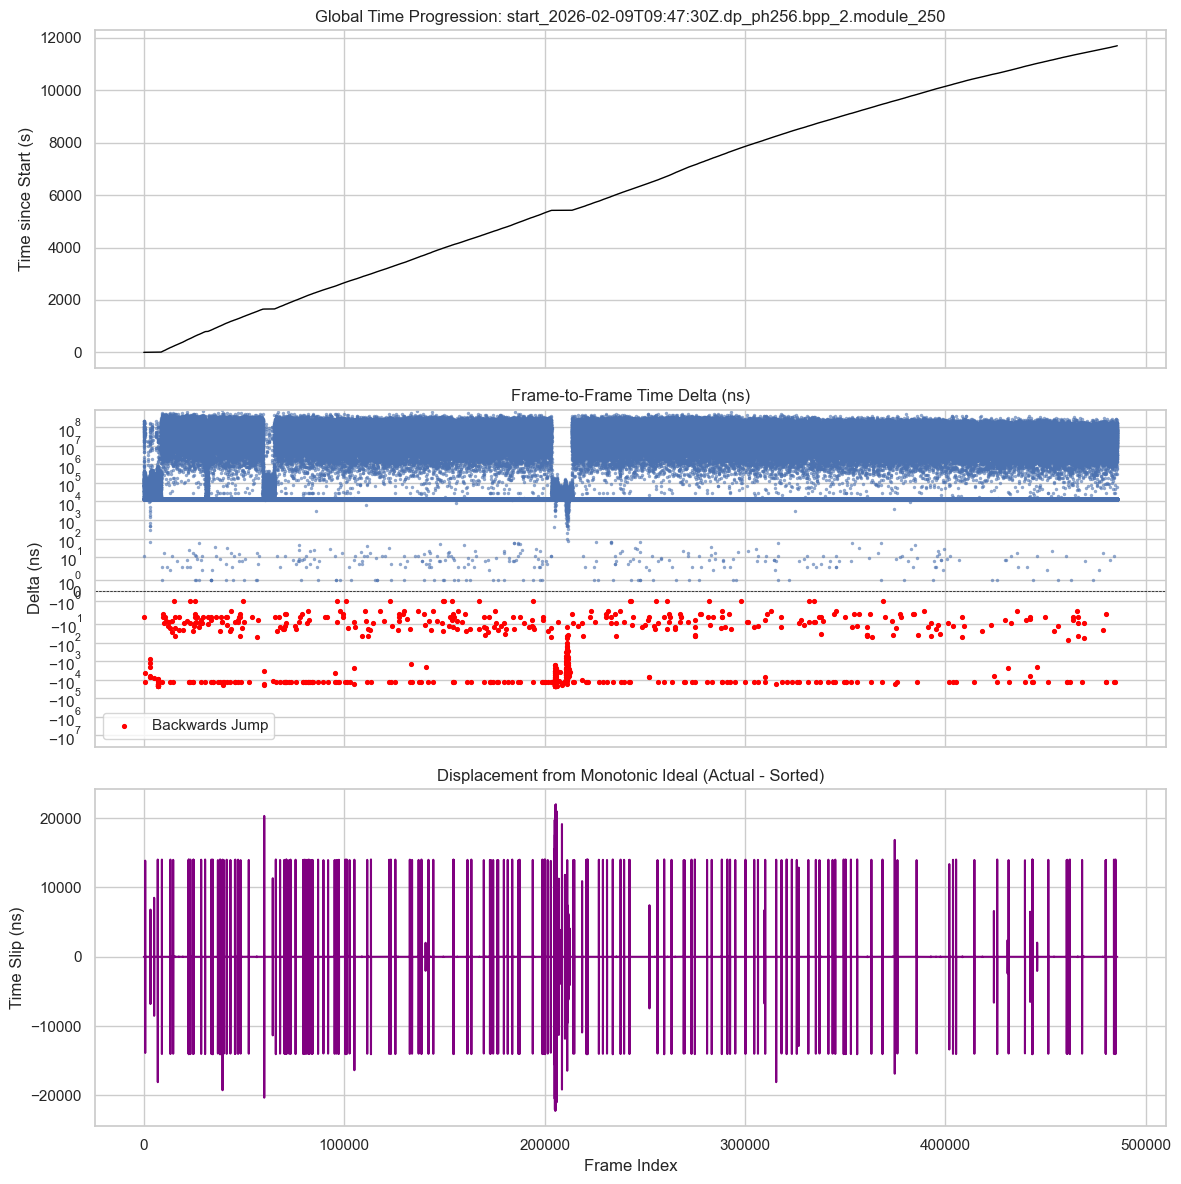

In [7]:
# --- Configuration ---
# Fetch all timestamps. 
# NOTE: For very large files (>1M frames), this might take a few seconds 
# as it parses every JSON header.
print(f"Fetching {len(seq)} timestamps for analysis...")

# Use a list comprehension with the optimized get_frame_time (returns int64 ns)
t0 = time.perf_counter()
timestamps_ns = np.array([seq.get_frame_time(i) for i in range(len(seq))], dtype=np.int64)
fetch_time = time.perf_counter() - t0
print(f"Fetched in {fetch_time:.2f}s ({len(seq)/fetch_time:,.0f} headers/sec)")

# --- Analysis ---
# 1. Calculate Deltas (Time[i] - Time[i-1])
deltas = np.diff(timestamps_ns)

# 2. Identify Out-of-Order (Negative Deltas)
out_of_order_mask = deltas < 0
num_ooo = np.sum(out_of_order_mask)
pct_ooo = (num_ooo / len(deltas)) * 100

# 3. Calculate "Lag" vs Ideal (Sorted)
# If data were perfectly monotonic, it would equal the sorted version
sorted_timestamps = np.sort(timestamps_ns)
displacement = timestamps_ns - sorted_timestamps

print(f"\n--- Chronology Report ---")
print(f"Total Frames:       {len(seq):,}")
print(f"Out-of-Order Jumps: {num_ooo:,} ({pct_ooo:.4f}%)")
if num_ooo > 0:
    min_jump = np.min(deltas)
    print(f"Worst Backward Jump: {min_jump:,} ns ({min_jump/1e6:.3f} ms)")
else:
    print("Stream is perfectly monotonic.")

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: The Timeline (Macro View)
# We subtract the start time to make the y-axis readable (Time since start)
t_zeroed = (timestamps_ns - timestamps_ns[0]) / 1e9 # Seconds
sns.lineplot(x=np.arange(len(seq)), y=t_zeroed, ax=axes[0], color='black', linewidth=1)
axes[0].set_title(f"Global Time Progression: {seq.name}")
axes[0].set_ylabel("Time since Start (s)")

# Plot 2: Frame-to-Frame Deltas (Micro View)
# Positive spikes = gaps/dropped packets. Negative spikes = out-of-order.
# We use pixels as x-axis
sns.scatterplot(x=np.arange(len(deltas)), y=deltas, ax=axes[1], s=5, alpha=0.6, edgecolor=None)
# Highlight negative deltas in red
if num_ooo > 0:
    bad_indices = np.where(out_of_order_mask)[0]
    bad_values = deltas[out_of_order_mask]
    axes[1].scatter(bad_indices, bad_values, color='red', s=7.5, label='Backwards Jump', zorder=5)
    axes[1].legend()

axes[1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title("Frame-to-Frame Time Delta (ns)")
axes[1].set_ylabel("Delta (ns)")
axes[1].set_yscale('symlog') # Handles negative log scale nicely

# Plot 3: Displacement from Monotonic Ideal
# Shows how far "off" a packet is from where it should be if sorted
sns.lineplot(x=np.arange(len(displacement)), y=displacement, ax=axes[2], color='purple')
axes[2].set_title("Displacement from Monotonic Ideal (Actual - Sorted)")
axes[2].set_ylabel("Time Slip (ns)")
axes[2].set_xlabel("Frame Index")

plt.tight_layout()
plt.show()